In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.models import RegresionLineal
from src.metrics import mse, rmse, mae
from src.data_preprocessing import preprocess_and_engineer, z_score_normalize, COLUMN_ORDER
from src.auxiliares import cross_validation_ecm, generar_features, entrenar_y_evaluar, learning_curve, plot_learning_curve
from src.data_splitting import split_val_train

In [53]:
datos_vivienda= pd.read_csv("datos/raw/casas_dev.csv")
print("Muestra random del dataset:")
print("====================================================================================================================")
muestras_aleatorias = datos_vivienda.sample(n=10, random_state=10)
print(muestras_aleatorias.to_string(index=False))
print("====================================================================================================================")

print("Cantidad de NaN por feature:")
print(datos_vivienda.isna().sum())
print("====================================================================================================================")

# evaluo la cantidad de muestras donde el precio es 0 para ver si seria significativo eliminarlas
zero_precio = (datos_vivienda["precio"] == 0).sum()
print("Cantidad de precios = 0:", zero_precio)
print("====================================================================================================================")
# cantidad total de muestras
total_muestras = len(datos_vivienda)
print("Cantidad total de muestras:", total_muestras)
print("====================================================================================================================")
#posible manipulacion a los datos de entrenamiento:
#seria buena idea unificar las unidades de los metros cubiertos y el area para no tratar con magnitudes distintas. Ademas, al ser pocos valores en comparacion con la cantidad total de muestras, eliminar las muestras con Nan en el feature precio ya que no nos sirven para entrenar el modelo, al igual que las que tienen precio 0 ya que lo mas seguro es que no tengan sentido y haya habido algun tipo de error al recolectar los datos.
#ademas al ser poca cantidad de datos, se puede observar y constatar que todas las muestras que tienen NaN en el feature "pisos", son deptos. Es por esto que para no perder las muestras, es util modificar esos NaN por 1.
print("Chequeo: todos los NaN de 'piso' pertecen a viviendas 'depto :")
print((datos_vivienda.loc[datos_vivienda["pisos"].isna(), "tipo"] == "depto").all()) #true si todos los nan en pisos son depto.

#es necesario analizar la importancia del feature "Edad" para predecir el precio de la vivienda. En caso de no serlo, podria eliminarse el feature o manipular los datos faltantes, asi como contemplar la posibilidad de eliminar esas filas.


Muestra random del dataset:
       precio  tipo       Área  metros_cubiertos unidades  ambientes  pisos  pileta        lat        lon      edad
 34345.120859  casa 225.850906        134.700518       m2         10    3.0   False -34.738635 -58.262268 36.263724
234271.666674 depto 705.675397        688.789363     sqft          6    NaN   False  40.797309 -73.996614  8.281259
 23667.464441  casa 210.489857        139.336163       m2          9    3.0    True -34.786691 -58.282121       NaN
233636.834421 depto 768.866569        749.997392     sqft          6    NaN   False  40.730957 -73.950460 12.139936
  9281.076493 depto  72.296585         70.643357       m2          7    NaN   False -34.708320 -58.264159  6.844900
   106.354645 depto  81.078428         77.935879       m2          2    NaN   False -34.810288 -58.277601 14.452241
198884.781839 depto 687.954328        686.420394     sqft          6    NaN   False  40.734175 -73.956497  6.017775
218135.716977 depto 752.308713        719.87

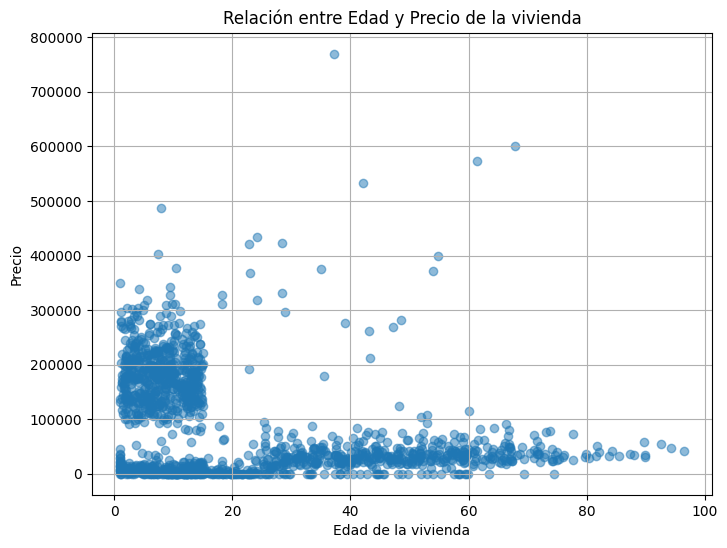

no se observa ninguna relacion monotonica entre la edad y el precio, por lo que creeriamos que no es de tanta importancia para la prediccion. Igualmente, lo mantendremos.


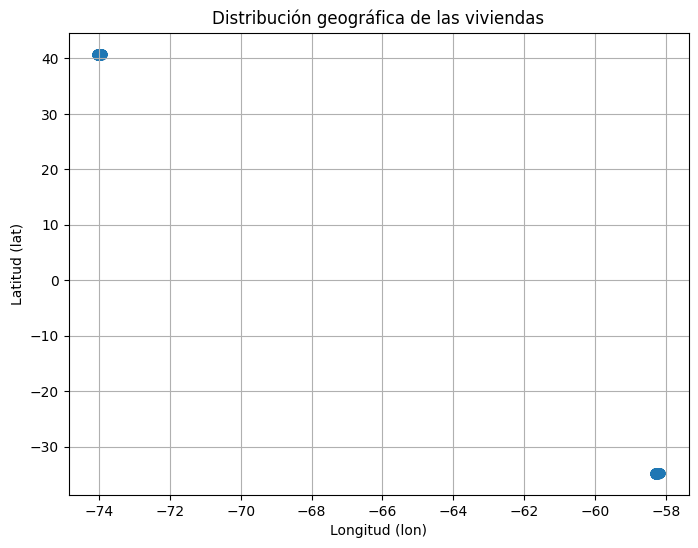

se pueden observar dos zonas claramente distintas. al buscarlas en el mapa obtenemos que son coordenadas de Capital Federal y de New York:


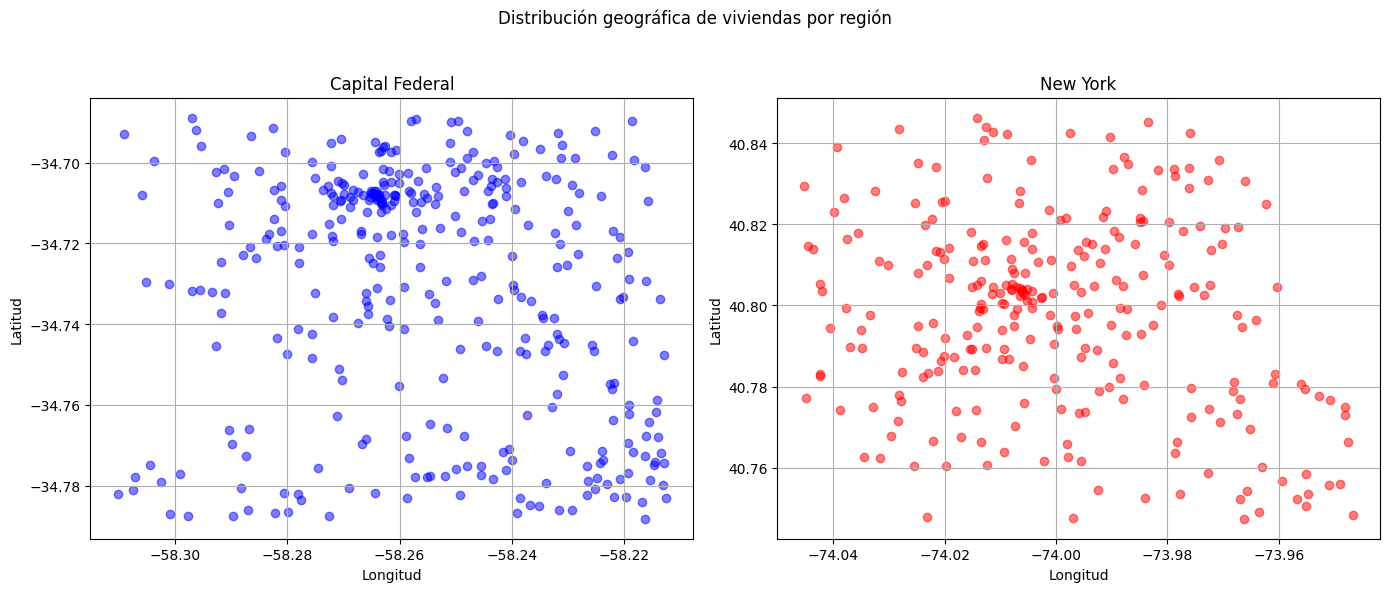

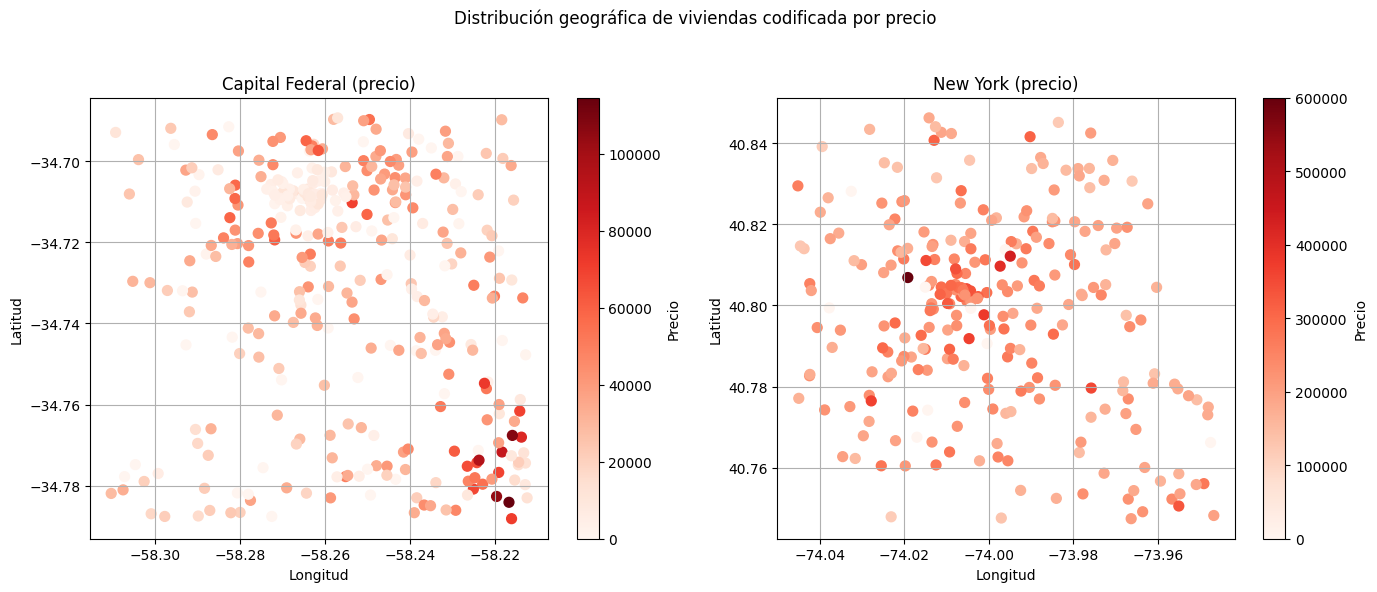

Se podria dividir el problema en dos y armar un modelo para cada cluster (Capital y New York), pero me quedarian dos datasets muy chicos. Es por esto que elijo crear un solo modelo con un dataset mas grande y evitar asi el overfitting.


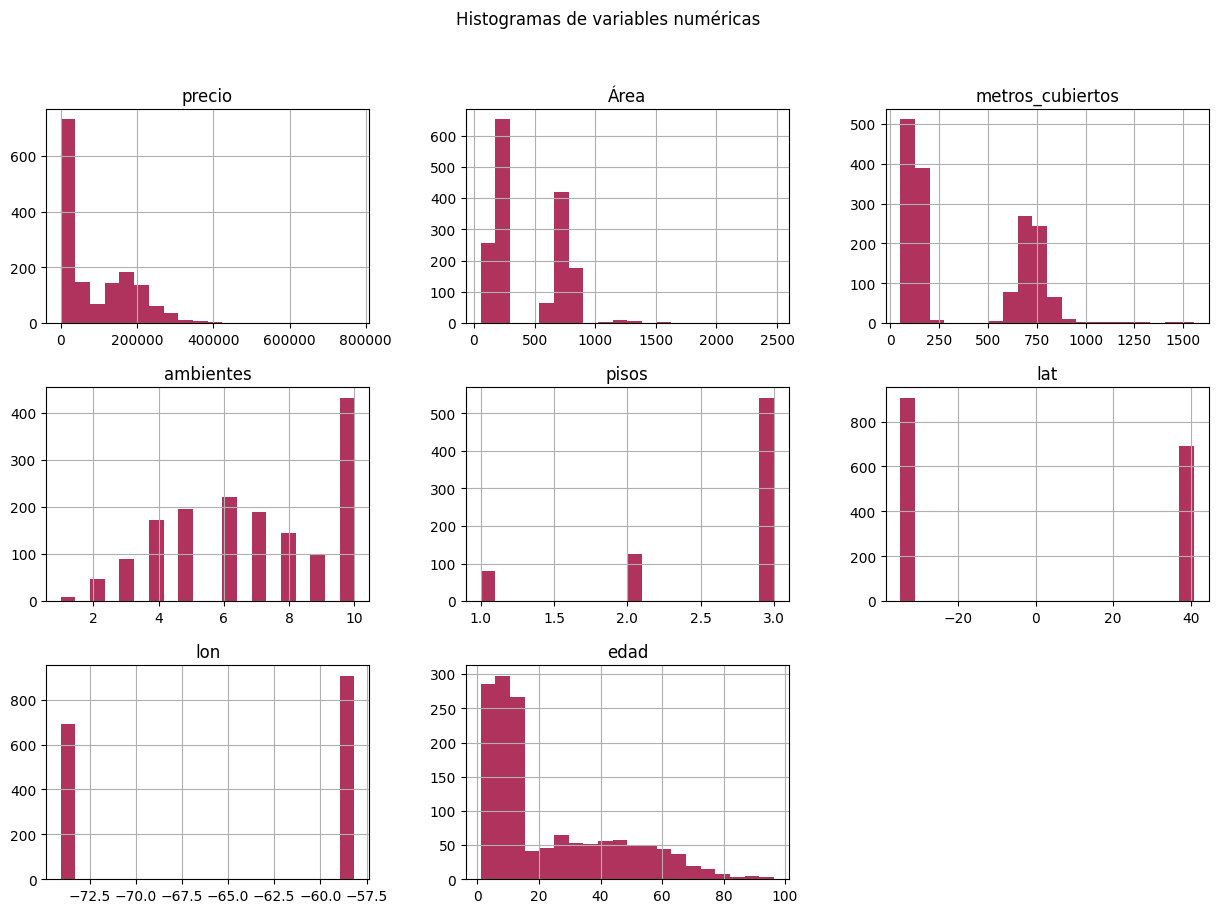

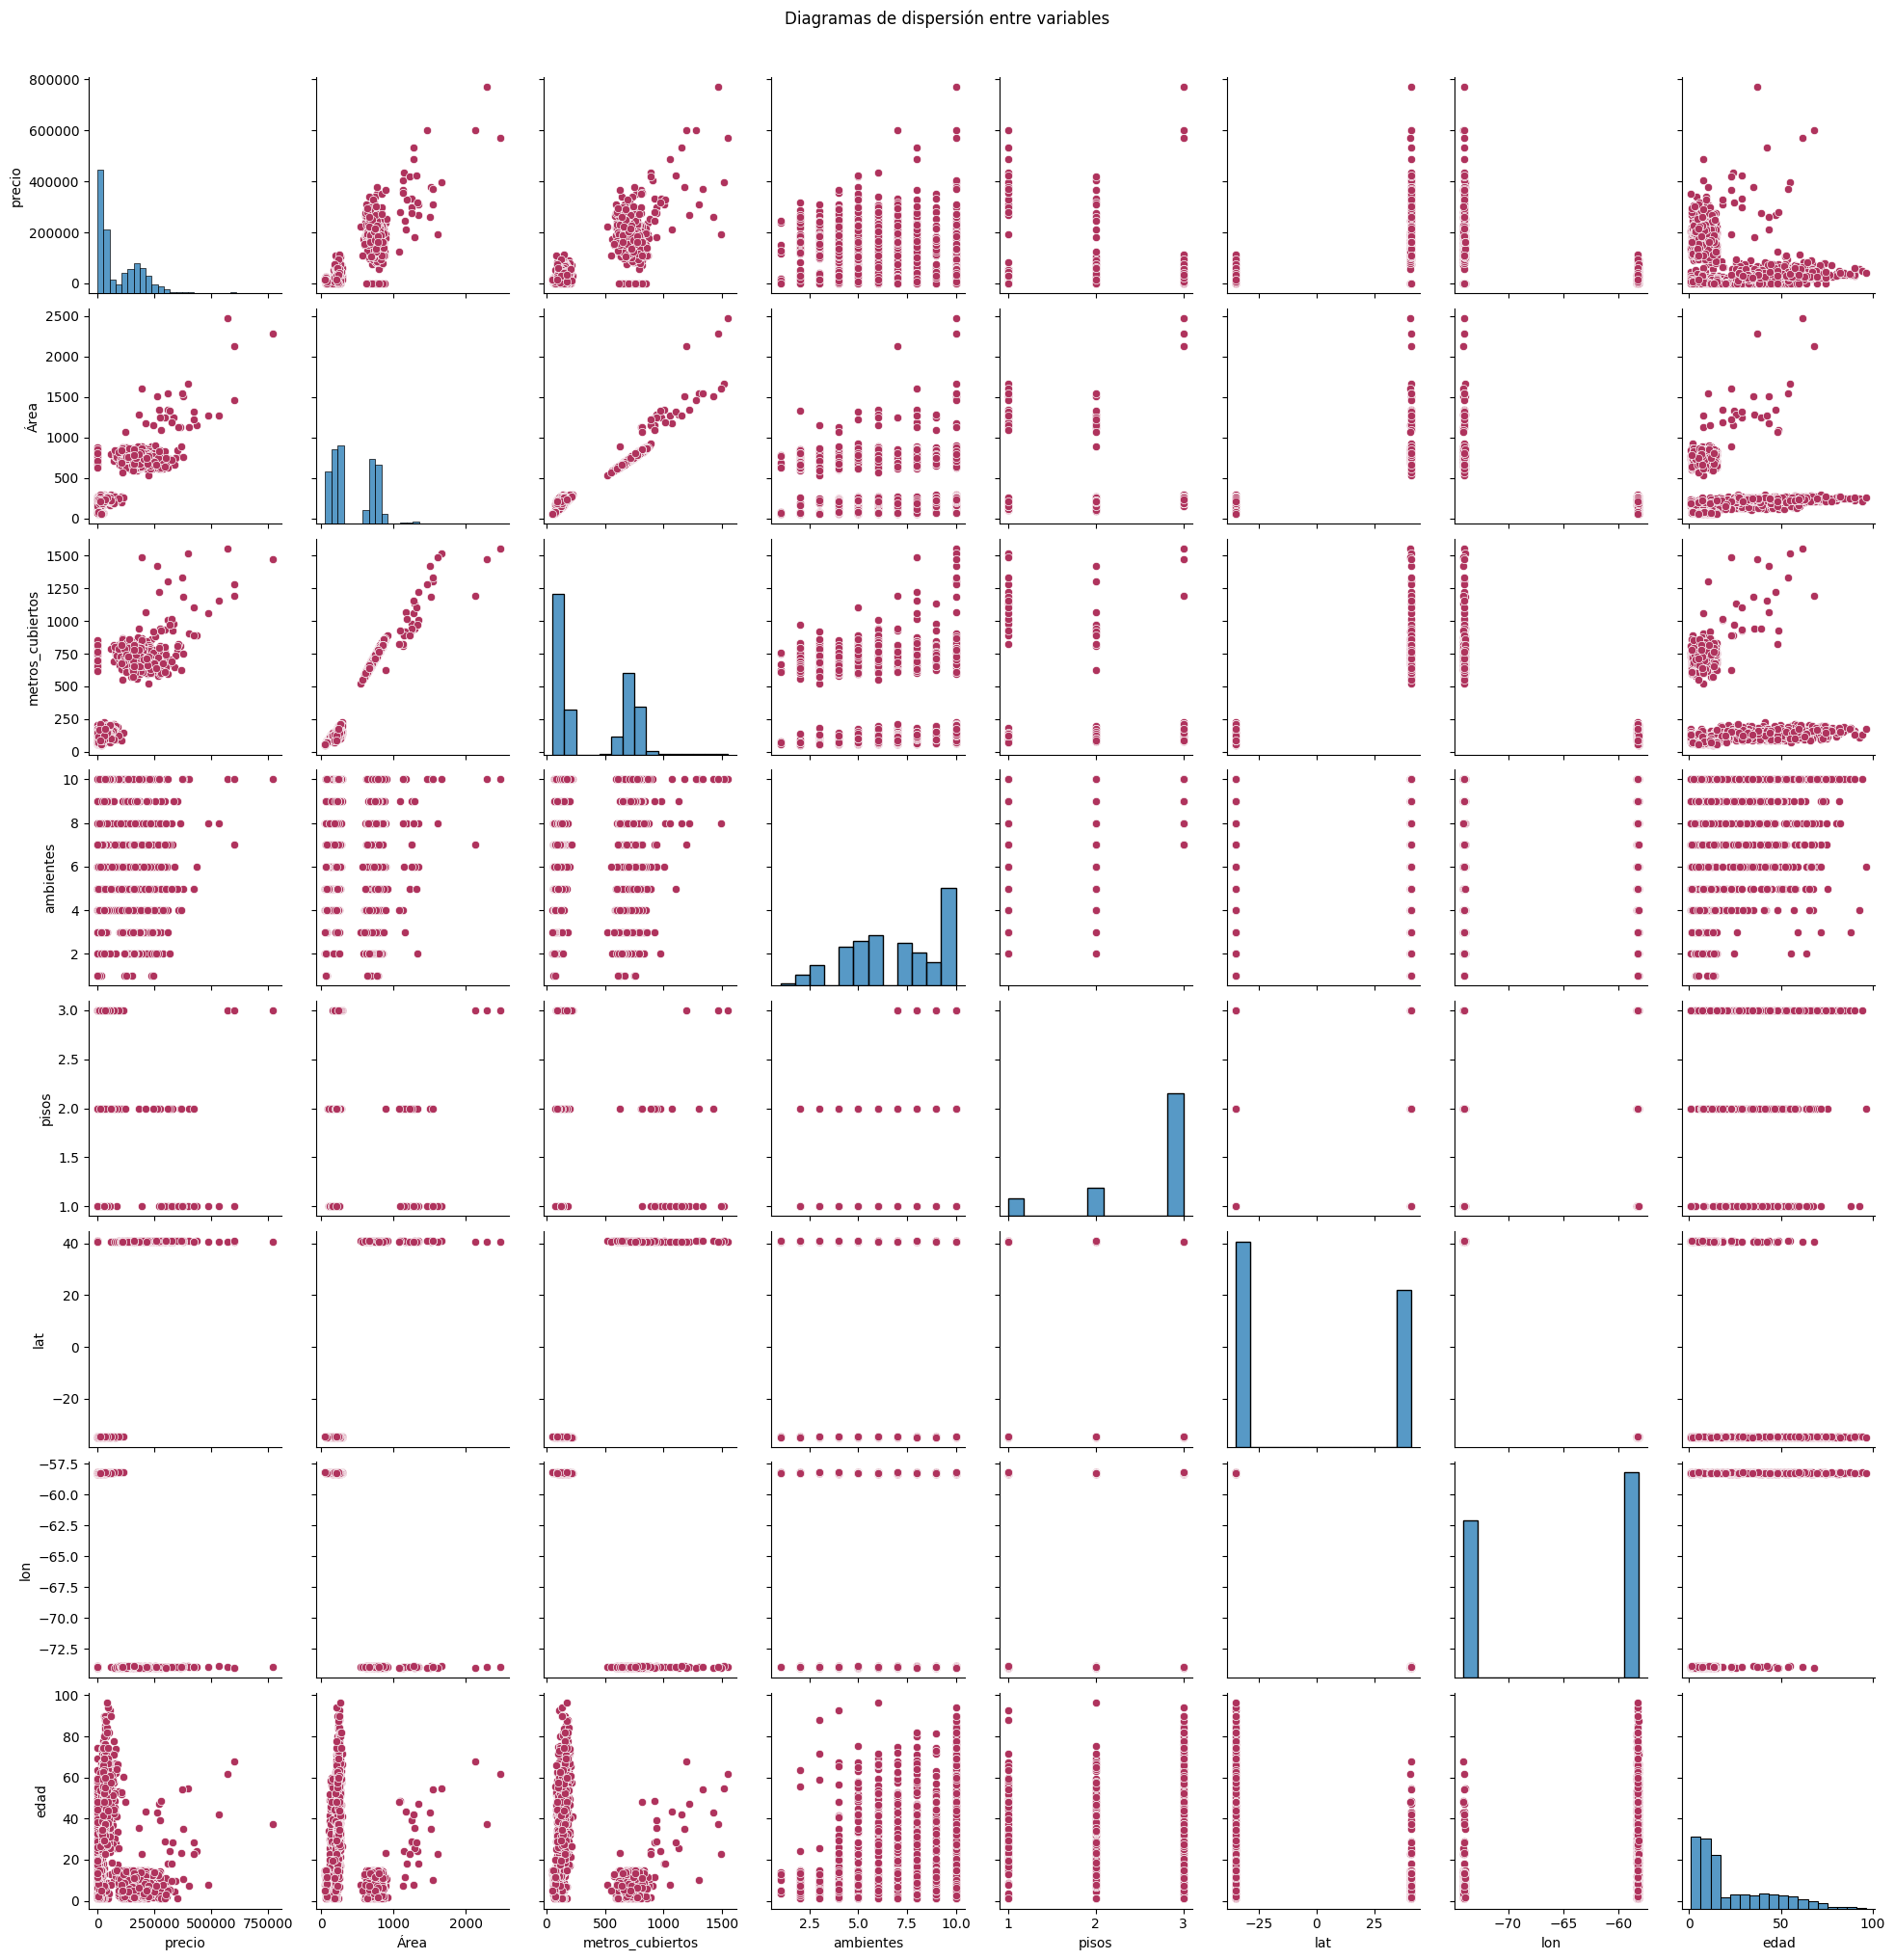

Podemos observar que area y metros cubiertos son las variables que mas correlacion tienen con el precio (tendencia positiva y lineal) 


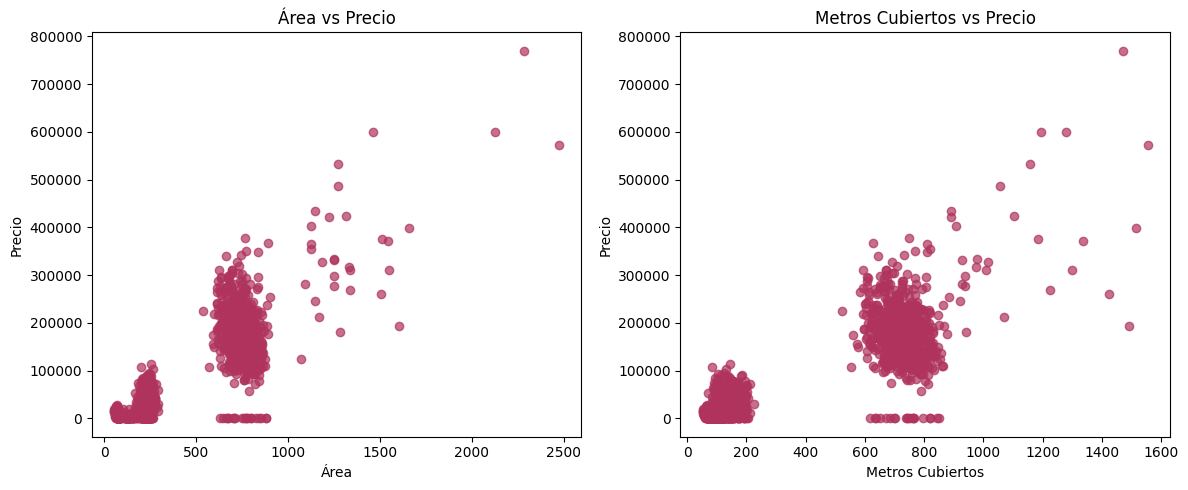

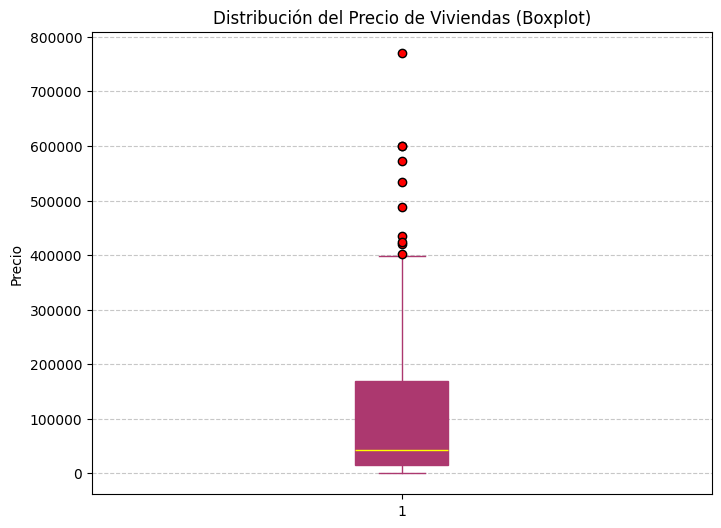

Se puede observar que hay un sesgo significativo hacia la izquierda y que apartir de 400000 hay outliers. Ademas, la median se encuentra entre los precios mas bajos.


In [54]:
#scatterplot edad vs precio
plt.figure(figsize=(8,6))
plt.scatter(datos_vivienda["edad"], datos_vivienda["precio"], alpha=0.5)
plt.xlabel("Edad de la vivienda")
plt.ylabel("Precio")
plt.title("Relación entre Edad y Precio de la vivienda")
plt.grid(True)
plt.show()

print("no se observa ninguna relacion monotonica entre la edad y el precio, por lo que creeriamos que no es de tanta importancia para la prediccion. Igualmente, lo mantendremos.")

#scatterplot de ubicaciones
plt.figure(figsize=(8,6))
plt.scatter(datos_vivienda["lon"], datos_vivienda["lat"], alpha=0.5)
plt.xlabel("Longitud (lon)")
plt.ylabel("Latitud (lat)")
plt.title("Distribución geográfica de las viviendas")
plt.grid(True)
plt.show()

print("se pueden observar dos zonas claramente distintas. al buscarlas en el mapa obtenemos que son coordenadas de Capital Federal y de New York:")

capital = (-34.738635, -58.262268)
new_york = (40.797309, -73.996614)
umbral = 0.05

argentina = datos_vivienda[
    (abs(datos_vivienda["lat"] - capital[0]) < umbral) & 
    (abs(datos_vivienda["lon"] - capital[1]) < umbral)
]

usa = datos_vivienda[
    (abs(datos_vivienda["lat"] - new_york[0]) < umbral) & 
    (abs(datos_vivienda["lon"] - new_york[1]) < umbral)
]


fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(argentina["lon"], argentina["lat"], color="blue", alpha=0.5)
axes[0].set_title("Capital Federal")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].grid(True)

axes[1].scatter(usa["lon"], usa["lat"], color="red", alpha=0.5)
axes[1].set_title("New York")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
axes[1].grid(True)

plt.suptitle("Distribución geográfica de viviendas por región")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#scatterplot segun precio
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# capital
norm_arg = plt.Normalize(vmin=argentina["precio"].min(), vmax=argentina["precio"].max())
axes[0].scatter(argentina["lon"], argentina["lat"], c=argentina["precio"], cmap="Reds", norm=norm_arg, s=50)
axes[0].set_title("Capital Federal (precio)")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].grid(True)
cbar0 = plt.colorbar(plt.cm.ScalarMappable(norm=norm_arg, cmap="Reds"), ax=axes[0])
cbar0.set_label("Precio")

#new york
norm_us = plt.Normalize(vmin=usa["precio"].min(), vmax=usa["precio"].max())
axes[1].scatter(usa["lon"], usa["lat"], c=usa["precio"], cmap="Reds", norm=norm_us, s=50)
axes[1].set_title("New York (precio)")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
axes[1].grid(True)
cbar1 = plt.colorbar(plt.cm.ScalarMappable(norm=norm_us, cmap="Reds"), ax=axes[1])
cbar1.set_label("Precio")

plt.suptitle("Distribución geográfica de viviendas codificada por precio")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Se podria dividir el problema en dos y armar un modelo para cada cluster (Capital y New York), pero me quedarian dos datasets muy chicos. Es por esto que elijo crear un solo modelo con un dataset mas grande y evitar asi el overfitting.")


paleta = ["#B44DB0", "#AC386F", "#A3295E", "#AF335D", "#BA3D5B", 
          "#D15157", "#DA6555", "#E27852", "#EA8B4F", "#F29E4C"]

numericas = datos_vivienda.select_dtypes(include=['float64', 'int64']) 

#histogramas
numericas.hist(bins=20, figsize=(15,10), color=paleta[3])
plt.suptitle("Histogramas de variables numéricas")
plt.show()

#pairplot
sns.pairplot(numericas, plot_kws={'color': paleta[3]})
plt.suptitle("Diagramas de dispersión entre variables", y=1.02)
plt.show()


print("Podemos observar que area y metros cubiertos son las variables que mas correlacion tienen con el precio (tendencia positiva y lineal) ")
plt.figure(figsize=(12,5))

#area vs precio
plt.subplot(1, 2, 1)
plt.scatter(datos_vivienda['Área'], datos_vivienda['precio'], color=paleta[3], alpha=0.7)
plt.xlabel("Área")
plt.ylabel("Precio")
plt.title("Área vs Precio")

#metros cubiertos vs precio
plt.subplot(1, 2, 2)
plt.scatter(datos_vivienda['metros_cubiertos'], datos_vivienda['precio'], color=paleta[3], alpha=0.7)
plt.xlabel("Metros Cubiertos")
plt.ylabel("Precio")
plt.title("Metros Cubiertos vs Precio")

plt.tight_layout()
plt.show()


#boxplot precio
plt.figure(figsize=(8,6))
plt.boxplot(datos_vivienda['precio'].dropna(), vert=True, patch_artist=True, #que filtre los valores NaN del precio
            boxprops=dict(facecolor='#AC386F', color='#AC386F'),
            medianprops=dict(color='yellow'),
            whiskerprops=dict(color='#AC386F'),
            capprops=dict(color='#AC386F'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none'))
plt.ylabel("Precio")
plt.title("Distribución del Precio de Viviendas (Boxplot)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Se puede observar que hay un sesgo significativo hacia la izquierda y que apartir de 400000 hay outliers. Ademas, la median se encuentra entre los precios mas bajos.")



Se observa una alta correlacion entre el precio y metros cubiertos y entre precio y area. Asimismo, new york tiene propiedades de menor area y mas caras mientras que en Buenos Aires es al reves, esto se puede ver en los graficos de pairplot.

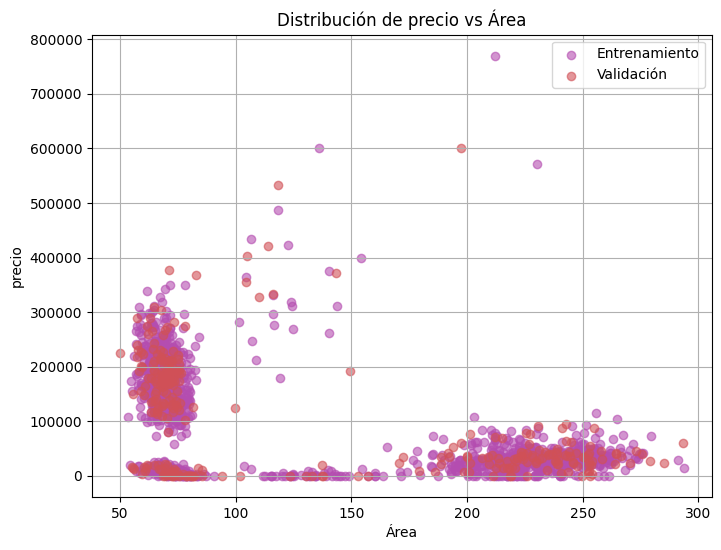

In [55]:
datos_vivienda_train = datos_vivienda.copy()

#elimino filas donde "precio" sea NaN o 0
datos_vivienda_train = datos_vivienda_train.dropna(subset=['precio'])
datos_vivienda_train = datos_vivienda_train[datos_vivienda_train['precio'] != 0]

#los NaN en "pisos" los reemplazo por 1
datos_vivienda_train['pisos'] = datos_vivienda_train['pisos'].fillna(1)

#binary encoding para "pileta" (1 si es True, 0 si es False)
datos_vivienda_train['pileta'] = datos_vivienda_train['pileta'].map({False: 0, True: 1})

#los Nan en "Edad" los reemplazo por la media  para no perder esas muestras
datos_vivienda_train['edad'] = datos_vivienda_train['edad'].fillna(datos_vivienda_train['edad'].mean())

#paso el Área y los metros cubiertos a m2
sqft_to_m2 = 0.092903
mask_sqft = datos_vivienda_train['unidades'] == 'sqft'
datos_vivienda_train.loc[mask_sqft, 'Área'] = datos_vivienda_train.loc[mask_sqft, 'Área'] * sqft_to_m2

#elimino la columna "unidades"
datos_vivienda_train = datos_vivienda_train.drop(columns=['unidades'])

#one hot encoding para "tipo"
datos_vivienda_train_encoded = pd.get_dummies(datos_vivienda_train, columns=['tipo'], drop_first=True)


datos_vivienda_train_encoded.to_csv("training_set/datos_vivienda_transformados.csv")


X = datos_vivienda_train_encoded.drop(columns=['precio'])
y = datos_vivienda_train_encoded['precio']


#split
dataset = pd.concat([X, y], axis=1)
X_train, X_val, y_train, y_val = split_val_train(dataset, target_column=y.name, test_size=0.2)

#guardar datasets spliteados
train_set = pd.concat([X_train, y_train], axis=1)
val_set = pd.concat([X_val, y_val], axis=1)
train_set.to_csv("datos/processed/split/train.csv", index=False)
val_set.to_csv("datos/processed/split/val.csv", index=False)

x_var = 'Área'
y_var = 'precio'

#grafico de ambos datasets
plt.figure(figsize=(8,6))
plt.scatter(X_train[x_var], y_train, color=paleta[0], alpha=0.6, label='Entrenamiento')
plt.scatter(X_val[x_var], y_val, color=paleta[5], alpha=0.6, label='Validación')
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Distribución de {y_var} vs {x_var}")
plt.legend()
plt.grid(True)
plt.show()

#normalizacion
X_mean = X_train.mean()
X_std = X_train.std()

#estandarizo
X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std 

#y no lo normalizo

# guardo los datasets como csv
X_train_scaled.to_csv("datos/processed/split/normalizados/X_train_scaled.csv", index=False)
X_val_scaled.to_csv("datos/processed/split/normalizados/X_val_scaled.csv", index=False)
pd.DataFrame(y_train, columns=["precio"]).to_csv(
    "datos/processed/split/normalizados/y_train.csv", index=False     #
)
pd.DataFrame(y_val, columns=["precio"]).to_csv(
    "datos/processed/split/normalizados/y_val.csv", index=False
)

In [56]:
#chequeo para ver si funciona para X vector y para X matriz de features
#ejemplo de regresion donde se quiere predecir que cantidad (en gramos) de comida se le debe dar a un animal dada cierta(s) caracteristicas del animal.
#x vector de features:
X_simple = pd.DataFrame({'peso': [5, 10, 15, 20, 25]})
y_simple = pd.Series([100, 200, 300, 400, 500])

X_simple_normalizado = (X_simple - X_simple.mean()) / X_simple.std()
modelo_simple = RegresionLineal(X_simple_normalizado, y_simple)
modelo_simple.array()  

print("chequeo de funcionamiento de la regresion lineal:")
print("########################    X como vector de features ########################" )
#con pseudo inversa
modelo_simple.pseudoinversa()
print("Coeficientes (pseudo-inversa):")
modelo_simple.imprimir_coef(nombres_columnas=X_simple.columns)

#con descenso por gradiente
modelo_simple.descenso_gradiente(alpha=0.01, iteraciones=1000)
print("Coeficientes (gradiente descendente):")
modelo_simple.imprimir_coef(nombres_columnas=X_simple.columns)

#X matriz de features
X_multi = pd.DataFrame({
    'Peso': [5, 10, 15, 20, 25],
    'Edad': [1, 3, 2, 5, 4],
    'Altura': [20, 30, 25, 40, 35]
})
y_multi = pd.Series([100, 200, 250, 400, 350])

X_multi_normalizado = (X_multi - X_multi.mean()) / X_multi.std()
modelo_multi = RegresionLineal(X_multi_normalizado, y_multi)
modelo_multi.array()  # convierte a numpy y agrega columna de unos

#con pseudo-inversa
modelo_multi.pseudoinversa()
print("Coeficientes (pseudo-inversa):")
modelo_multi.imprimir_coef(nombres_columnas=X_multi.columns)

#con descenso por gradiente
modelo_multi.descenso_gradiente(alpha=0.001, iteraciones=5000)
print("Coeficientes (gradiente descendente):")
modelo_multi.imprimir_coef(nombres_columnas=X_multi.columns)

print("tiene sentido que a lo que mas atencion le preste a la hora de predecir la cantidad de alimento sea el peso del animal.")
''

chequeo de funcionamiento de la regresion lineal:
########################    X como vector de features ########################
Coeficientes (pseudo-inversa):
                 Feature  Coeficiente
0  Término independiente   300.000000
1                   peso   158.113883
Coeficientes (gradiente descendente):
                 Feature  Coeficiente
0  Término independiente   299.987049
1                   peso   158.062521
Coeficientes (pseudo-inversa):
                 Feature  Coeficiente
0  Término independiente   260.000000
1                   Peso    61.488732
2                   Edad    30.744366
3                 Altura    30.744366
Coeficientes (gradiente descendente):
                 Feature  Coeficiente
0  Término independiente   258.252511
1                   Peso    53.358206
2                   Edad    34.488116
3                 Altura    34.488116
tiene sentido que a lo que mas atencion le preste a la hora de predecir la cantidad de alimento sea el peso del animal.


''

In [57]:
#cargar datos
X_train = pd.read_csv("datos/processed/split/normalizados/X_train_scaled.csv") 
y_train = pd.read_csv("datos/processed/split/normalizados/y_train.csv").squeeze().values.ravel()

X_val = pd.read_csv("datos/processed/split/normalizados/X_val_scaled.csv")
y_val = pd.read_csv("datos/processed/split/normalizados/y_val.csv").squeeze().values.ravel()

#modelo M1
X_train_M1 = X_train[['Área']]
print("#################################### MODELO M1 #############################################")


modelo_M1 = RegresionLineal(X_train_M1, y_train)
modelo_M1.array()

#gradiente descendente
theta_gd, historial_costos = modelo_M1.descenso_gradiente(alpha=0.01, iteraciones=10000)
print("Coeficientes M1 (gradiente descendente):")
modelo_M1.imprimir_coef(nombres_columnas=X_train_M1.columns)
y_pred_M1_gd = modelo_M1.predecir(X_val[['Área']])
print("ECM:", mse(y_val, y_pred_M1_gd), "RMSE:", rmse(y_val, y_pred_M1_gd), "MAE:", mae(y_val, y_pred_M1_gd))

# pseudo inversa
modelo_M1.pseudoinversa()
print("Coeficientes M1 (pseudo-inversa):")
modelo_M1.imprimir_coef(nombres_columnas=X_train_M1.columns)

y_pred_M1_pi = modelo_M1.predecir(X_val[['Área']])
print("ECM:", mse(y_val, y_pred_M1_pi), "RMSE:", rmse(y_val, y_pred_M1_pi), "MAE:", mae(y_val, y_pred_M1_pi))

#modelo m2
X_train_M2 = X_train[['Área', 'pileta']]
print("#################################### MODELO M2 #############################################")
modelo_M2 = RegresionLineal(X_train_M2, y_train)
modelo_M2.array()

theta_gd2, historial_costos2 = modelo_M2.descenso_gradiente(alpha=0.001, iteraciones=10000)
print("Coeficientes M2 (gradiente descendente):")
modelo_M2.imprimir_coef(nombres_columnas=X_train_M2.columns)

y_pred_M2_gd = modelo_M2.predecir(X_val[['Área', 'pileta']])
print("ECM:", mse(y_val, y_pred_M2_gd), "RMSE:", rmse(y_val, y_pred_M2_gd), "MAE:", mae(y_val, y_pred_M2_gd))

modelo_M2.pseudoinversa()
print("Coeficientes M2 (pseudo-inversa):")
modelo_M2.imprimir_coef(nombres_columnas=X_train_M2.columns)

y_pred_M2_pi = modelo_M2.predecir(X_val[['Área', 'pileta']])
print("ECM:", mse(y_val, y_pred_M2_pi), "RMSE:", rmse(y_val, y_pred_M2_pi), "MAE:", mae(y_val, y_pred_M2_pi))


#################################### MODELO M1 #############################################
Coeficientes M1 (gradiente descendente):
                 Feature   Coeficiente
0  Término independiente  95043.645690
1                   Área -53449.603278
ECM: 8084192222.551176 RMSE: 89912.13612494798 MAE: 60900.48514784339
Coeficientes M1 (pseudo-inversa):
                 Feature   Coeficiente
0  Término independiente  95043.645691
1                   Área -53449.603279
ECM: 8084192222.544302 RMSE: 89912.13612490975 MAE: 60900.48514775701
#################################### MODELO M2 #############################################
Coeficientes M2 (gradiente descendente):
                 Feature   Coeficiente
0  Término independiente  95039.352251
1                   Área -51683.020490
2                 pileta  -3224.856076
ECM: 8071335202.428774 RMSE: 89840.60998473226 MAE: 60956.67063304259
Coeficientes M2 (pseudo-inversa):
                 Feature   Coeficiente
0  Término independiente 

In [58]:
print("Consigna:Benito está evaluando la posibilidad de construir una pileta. ¿Cómo afectaría la construcción de una pileta al precio de su propiedad? Explique cómo llegó a este resultado.")
print("Esta pregunta se puede responder con los coeficientes obtenidos de la misma regresion lineal. Este coeficiente indica que tan importante para el precio de una vivienda es tener o no una pileta ")
print(" Es por esto que el coeficiente obtenido -3218.049692 indica que tener una pileta reduciria el  precio esperado de la vivienda en ese monto de dinero, dados los datos observados. ")

Consigna:Benito está evaluando la posibilidad de construir una pileta. ¿Cómo afectaría la construcción de una pileta al precio de su propiedad? Explique cómo llegó a este resultado.
Esta pregunta se puede responder con los coeficientes obtenidos de la misma regresion lineal. Este coeficiente indica que tan importante para el precio de una vivienda es tener o no una pileta 
 Es por esto que el coeficiente obtenido -3218.049692 indica que tener una pileta reduciria el  precio esperado de la vivienda en ese monto de dinero, dados los datos observados. 


In [59]:
#modelo M3
columnas_M3 = ["Área", "metros_cubiertos", "pileta", "ambientes", "pisos", "edad"]
X_train_M3 = X_train[columnas_M3]  # solo las columnas seleccionadas
modelo_M3 = RegresionLineal(X_train_M3, y_train)
modelo_M3.array()

theta_gd3, historial_costos3 = modelo_M3.descenso_gradiente(alpha=0.001, iteraciones=10000)
print("Coeficientes M3 (gradiente descendente):")
modelo_M3.imprimir_coef(nombres_columnas=X_train_M3.columns)

y_pred_gd3 = np.dot(np.hstack([np.ones((X_val[columnas_M3].shape[0], 1)), X_val[columnas_M3]]), modelo_M3.coef)

mse_gd3 = mse(y_val, y_pred_gd3)
rmse_gd3 = rmse(y_val, y_pred_gd3)
mae_gd3 = mae(y_val, y_pred_gd3)

print("ECM M3 (gradiente descendente):", mse_gd3)
print("RMSE M3 (gradiente descendente):", rmse_gd3)
print("MAE M3 (gradiente descendente):", mae_gd3)

modelo_M3.pseudoinversa()
print("Coeficientes M3 (pseudo-inversa):")
modelo_M3.imprimir_coef(nombres_columnas=X_train_M3.columns)

y_pred_pi3 = np.dot(np.hstack([np.ones((X_val[columnas_M3].shape[0], 1)), X_val[columnas_M3]]), modelo_M3.coef)

mse_pi3 = mse(y_val, y_pred_pi3)
rmse_pi3 = rmse(y_val, y_pred_pi3)
mae_pi3 = mae(y_val, y_pred_pi3)

print("ECM M3 (pseudo-inversa):", mse_pi3)
print("RMSE M3 (pseudo-inversa):", rmse_pi3)
print("MAE M3 (pseudo-inversa):", mae_pi3)

Coeficientes M3 (gradiente descendente):
                 Feature   Coeficiente
0  Término independiente  95039.352251
1                   Área  -4738.999767
2       metros_cubiertos  85067.882225
3                 pileta   2295.685459
4              ambientes  -2436.609776
5                  pisos   1671.397141
6                   edad   7962.458268
ECM M3 (gradiente descendente): 2496808780.4702
RMSE M3 (gradiente descendente): 49968.07761431492
MAE M3 (gradiente descendente): 30522.69976777396
Coeficientes M3 (pseudo-inversa):
                 Feature   Coeficiente
0  Término independiente  95043.645691
1                   Área  -4827.119144
2       metros_cubiertos  85775.420550
3                 pileta   2128.127569
4              ambientes  -3260.128203
5                  pisos   3271.361171
6                   edad   7706.220004
ECM M3 (pseudo-inversa): 2484869440.187952
RMSE M3 (pseudo-inversa): 49848.46477262818
MAE M3 (pseudo-inversa): 30442.34239708269


Features nuevas mas correlacionadas con precio: ['log_cubiertos', 'cubiertos_ratio', 'cubiertos_x_pisos', 'log_area', 'sqrt_area', 'area_x_ambientes']


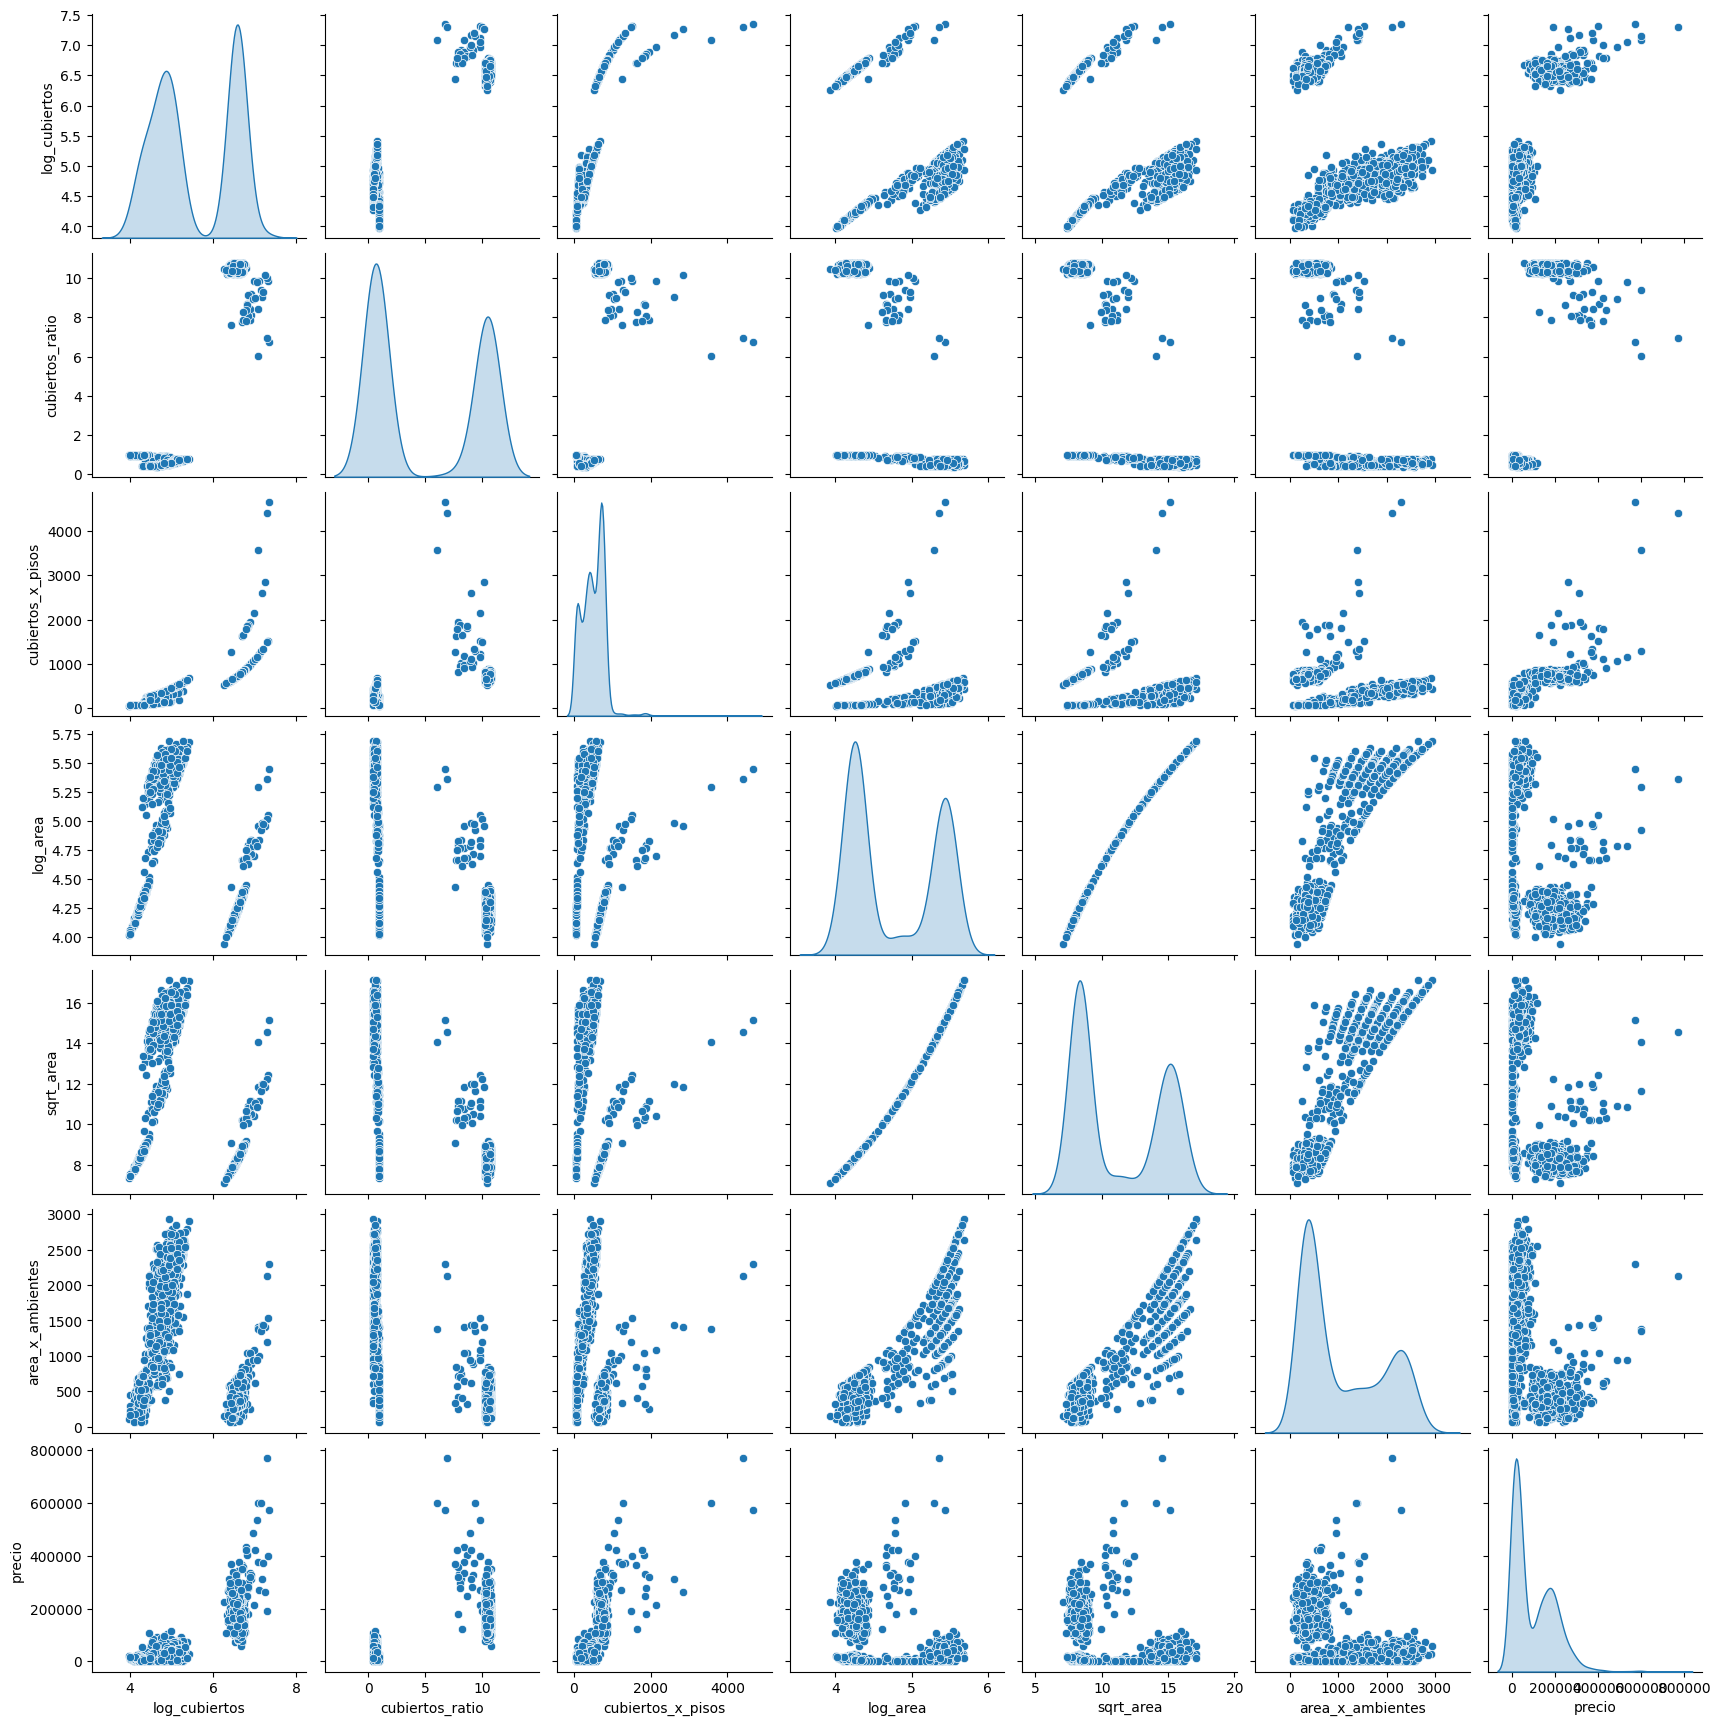

In [60]:
datos_vivienda_train["cubiertos_ratio"] = datos_vivienda_train["metros_cubiertos"] / datos_vivienda_train["Área"]
datos_vivienda_train["ambientes_por_m2"] = datos_vivienda_train["ambientes"] / datos_vivienda_train["Área"]
datos_vivienda_train["pisos_por_area"] = datos_vivienda_train["pisos"] / datos_vivienda_train["Área"]
datos_vivienda_train["ambientes_por_piso"] = datos_vivienda_train["ambientes"] / (
    datos_vivienda_train["pisos"].replace(0, np.nan)
)
datos_vivienda_train["area_x_ambientes"] = datos_vivienda_train["Área"] * datos_vivienda_train["ambientes"]
datos_vivienda_train["cubiertos_x_pisos"] = datos_vivienda_train["metros_cubiertos"] * datos_vivienda_train["pisos"]

datos_vivienda_train["log_area"] = np.log1p(datos_vivienda_train["Área"])
datos_vivienda_train["log_cubiertos"] = np.log1p(datos_vivienda_train["metros_cubiertos"])
datos_vivienda_train["edad2"] = datos_vivienda_train["edad"] ** 2
datos_vivienda_train["sqrt_area"] = np.sqrt(datos_vivienda_train["Área"])

#busco correlacion para ver cuales son los features mas importantes
features_nuevas = [
    "cubiertos_ratio", "ambientes_por_m2", "pisos_por_area", "ambientes_por_piso",
    "area_x_ambientes", "cubiertos_x_pisos",
    "log_area", "log_cubiertos", "edad2", "sqrt_area"
]

corr = datos_vivienda_train[features_nuevas + ["precio"]].corr()

#elijo los que mas aportan al modelo
top_features_nuevas = corr["precio"].drop("precio").abs().sort_values(ascending=False).head(6).index.tolist()

print("Features nuevas mas correlacionadas con precio:", top_features_nuevas)

#grafico
sns.pairplot(datos_vivienda_train[top_features_nuevas + ["precio"]], diag_kind="kde")
plt.show()


In [61]:
datos_vivienda = pd.read_csv("datos/raw/casas_dev.csv").copy()

datos_vivienda = datos_vivienda.dropna(subset=['precio'])
datos_vivienda = datos_vivienda[datos_vivienda['precio'] != 0]

datos_vivienda['pisos'] = datos_vivienda['pisos'].fillna(1)
datos_vivienda['edad'] = datos_vivienda['edad'].fillna(datos_vivienda['edad'].mean())
datos_vivienda['pileta'] = datos_vivienda['pileta'].map({False: 0, True: 1})
sqft_to_m2 = 0.092903
mask_sqft = datos_vivienda['unidades'] == 'sqft'
datos_vivienda.loc[mask_sqft, 'Área'] = datos_vivienda.loc[mask_sqft, 'Área'] * sqft_to_m2
datos_vivienda = datos_vivienda.drop(columns=['unidades'])

#features nuevas
datos_vivienda["cubiertos_ratio"] = datos_vivienda["metros_cubiertos"] / datos_vivienda["Área"]
datos_vivienda["cubiertos_x_pisos"] = datos_vivienda["metros_cubiertos"] * datos_vivienda["pisos"]
datos_vivienda["log_area"] = np.log1p(datos_vivienda["Área"])
datos_vivienda["sqrt_area"] = np.sqrt(datos_vivienda["Área"])
datos_vivienda["area_x_ambientes"] = datos_vivienda["Área"] * datos_vivienda["ambientes"]
datos_vivienda["ambientes_x_pisos"] = datos_vivienda["ambientes"] * datos_vivienda["pisos"]

#one hot encoding
datos_vivienda_encoded = pd.get_dummies(datos_vivienda, columns=['tipo'], drop_first=True)

features_nuevos = [
    "cubiertos_ratio", "cubiertos_x_pisos", "log_area", 
    "sqrt_area", "area_x_ambientes", "ambientes_x_pisos"
]
features_originales = [
    "metros_cubiertos", "Área", "pisos", "ambientes", 
    "edad", "pileta"
]
tipo_columnas = [c for c in datos_vivienda_encoded.columns if c.startswith("tipo_")]

features_M4 = features_originales + features_nuevos + tipo_columnas

X_M4 = datos_vivienda_encoded[features_M4]
y_M4 = datos_vivienda_encoded["precio"]

#split
dataset = pd.concat([X_M4, y_M4], axis=1)  
X_train_M4, X_val_M4, y_train_M4, y_val_M4 = split_val_train(dataset, target_column=y.name, test_size=0.2)

#normalizacion
mu = X_train_M4.mean()
sigma = X_train_M4.std()

X_train_scaled_M4 = (X_train_M4 - mu) / sigma
X_val_scaled_M4 = (X_val_M4 - mu) / sigma

X_train_scaled_M4 = pd.DataFrame(X_train_scaled_M4, columns=X_train_M4.columns)
X_val_scaled_M4 = pd.DataFrame(X_val_scaled_M4, columns=X_val_M4.columns)

x_train_para_test=X_train_scaled_M4.copy() #lo uso en el ultimo punto para test
y_train_para_test=y_train_M4.copy()

#entrenamiento
modelo_M4 = RegresionLineal(X_train_scaled_M4, y_train_M4)
modelo_M4.array()

modelo_M4.pseudoinversa()
coef_pseudo_inversa = modelo_M4.coef.copy()
print("Coeficientes luego de entrenar por pseudoinversa:")
modelo_M4.imprimir_coef(nombres_columnas=X_train_scaled_M4.columns)

y_pred_pseudo_inversa = np.dot(
    np.hstack([np.ones((X_val_scaled_M4.shape[0], 1)), X_val_scaled_M4]), 
    modelo_M4.coef
)

#metricas
mse_pseudo_inversa = mse(y_val_M4, y_pred_pseudo_inversa)
rmse_pseudo_inversa = rmse(y_val_M4, y_pred_pseudo_inversa)
mae_pseudo_inversa = mae(y_val_M4, y_pred_pseudo_inversa)

print(f"ECM para el modelo con pseudo-inversa: {mse_pseudo_inversa}")
print(f"RMSE para el modelo con pseudo-inversa: {rmse_pseudo_inversa}")
print(f"MAE para el modelo con pseudo-inversa: {mae_pseudo_inversa}")

alpha = 0.001
iteraciones = 10000
theta, historial_costos = modelo_M4.descenso_gradiente(alpha, iteraciones)
coef_descenso_gradiente = modelo_M4.coef.copy()

print("Coeficientes luego de entrenar por descenso por gradiente:")
modelo_M4.imprimir_coef(nombres_columnas=X_train_scaled_M4.columns)

y_pred_descenso_gradiente = np.dot(
    np.hstack([np.ones((X_val_scaled_M4.shape[0], 1)), X_val_scaled_M4]), 
    modelo_M4.coef
)

mse_descenso_gradiente = mse(y_val_M4, y_pred_descenso_gradiente)
rmse_descenso_gradiente = rmse(y_val_M4, y_pred_descenso_gradiente)
mae_descenso_gradiente = mae(y_val_M4, y_pred_descenso_gradiente)

print(f"ECM para el modelo con descenso por gradiente: {mse_descenso_gradiente}")
print(f"RMSE para el modelo con descenso por gradiente: {rmse_descenso_gradiente}")
print(f"MAE para el modelo con descenso por gradiente: {mae_descenso_gradiente}")

Coeficientes luego de entrenar por pseudoinversa:
                  Feature    Coeficiente
0   Término independiente   95043.645691
1        metros_cubiertos  101982.430792
2                    Área -307338.287238
3                   pisos    7544.326983
4               ambientes    6132.298368
5                    edad    5454.348214
6                  pileta    1909.862468
7         cubiertos_ratio  -36188.794255
8       cubiertos_x_pisos   11016.529050
9                log_area -661868.562955
10              sqrt_area  850901.599009
11       area_x_ambientes   28781.392441
12      ambientes_x_pisos  -42105.631344
13             tipo_depto -103442.546145
14                tipo_ph  -18798.685727
ECM para el modelo con pseudo-inversa: 2030206104.4820223
RMSE para el modelo con pseudo-inversa: 45057.80847402615
MAE para el modelo con pseudo-inversa: 30094.41474892897
Coeficientes luego de entrenar por descenso por gradiente:
                  Feature   Coeficiente
0   Término independie

In [62]:
#limpio dataset
datos_vivienda = pd.read_csv("datos/raw/casas_dev.csv").copy()
datos_vivienda = datos_vivienda.dropna(subset=['precio'])
datos_vivienda = datos_vivienda[datos_vivienda['precio'] != 0]
datos_vivienda['pisos'] = datos_vivienda['pisos'].fillna(1)
datos_vivienda['edad'] = datos_vivienda['edad'].fillna(datos_vivienda['edad'].mean())
datos_vivienda['pileta'] = datos_vivienda['pileta'].map({False: 0, True: 1})
sqft_to_m2 = 0.092903
mask_sqft = datos_vivienda['unidades'] == 'sqft'
datos_vivienda.loc[mask_sqft, 'Área'] *= sqft_to_m2
datos_vivienda = datos_vivienda.drop(columns=['unidades'])

features = ["metros_cubiertos", "Área", "pisos", "ambientes", "edad", "pileta", "lat", "lon"]
X_base = datos_vivienda[features].copy()
y = datos_vivienda["precio"].copy()


#split de los datos
dataset = pd.concat([X_base, y], axis=1) 
X_train_M4, X_val_M4, y_train_M4, y_val_M4 = split_val_train(dataset, target_column=y.name, test_size=0.2)


#normalizacion
mu = X_train.mean()
sigma = X_train.std()
X_train_scaled = (X_train - mu) / sigma
X_val_scaled = (X_val - mu) / sigma

#agrego features nuevos
X_train_M5_alt = generar_features(X_train_scaled, features, max_cols=50)
X_val_M5_alt   = generar_features(X_val_scaled, features, max_cols=50)

min_rows = min(X_val_M5_alt.shape[0], y_val.shape[0])
X_val_M5_alt = X_val_M5_alt.iloc[:min_rows, :]
y_val = pd.Series(y_val)

min_rows = min(X_val_M5_alt.shape[0], y_val.shape[0])
X_val_M5_alt = X_val_M5_alt.iloc[:min_rows, :]
y_val_aligned = y_val.iloc[:min_rows]


#entrenamiento y validacion de M5
modelo_M5_alt = RegresionLineal(X_train_M5_alt, y_train)
modelo_M5_alt.array()

mse_train_gd, mse_val_gd, mse_train_pi, mse_val_pi = entrenar_y_evaluar(
    modelo_M5_alt, X_train_M5_alt, y_train, X_val_M5_alt, y_val_aligned
)

print("Dada la alta cantidad de features para la misma cantidad de datos de M4, se espera que al chequear error con el dataset de test me de que no generaliza bien (overfitting) y que se ajusta demasiado a los datos del train.")
print("ECM M5 alternativo (gradiente descendente) - train:", mse_train_gd)
print("ECM M5 alternativo (gradiente descendente) - validation:", mse_val_gd)
print("ECM M5 alternativo (pseudo-inversa) - train:", mse_train_pi)
print("ECM M5 alternativo (pseudo-inversa) - validation:", mse_val_pi)
print("Dado que el valor de validation es bastante mayor que el de train se puede confirmar que esta ajustandose demasiado a los datos. Este no seria el modelo mas optimo para entrenar" )


Dada la alta cantidad de features para la misma cantidad de datos de M4, se espera que al chequear error con el dataset de test me de que no generaliza bien (overfitting) y que se ajusta demasiado a los datos del train.
ECM M5 alternativo (gradiente descendente) - train: 1697757829.814192
ECM M5 alternativo (gradiente descendente) - validation: 2746616093.637066
ECM M5 alternativo (pseudo-inversa) - train: 1113731690.6076896
ECM M5 alternativo (pseudo-inversa) - validation: 1821486178.9386692
Dado que el valor de validation es bastante mayor que el de train se puede confirmar que esta ajustandose demasiado a los datos. Este no seria el modelo mas optimo para entrenar


¿Qué resultados esperaba obtener con estos experimentos? Esperaba que el segundo modelo tienda mas a overfittear debido a la cantidad de features que contiene. Por el contrario, esperaba que el M4 sea bastante bueno debido a que agregue features que se creen importantes para predecir el target.

#regularizacion

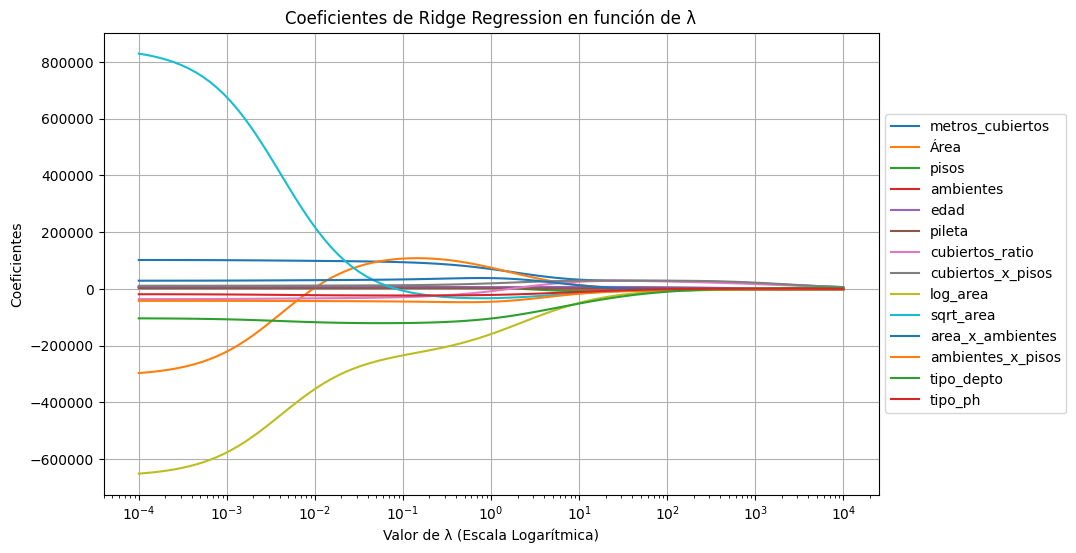

A continuación se imprimen los valores de los coeficientes con el lambda más chico y el más grande.
Esto se hace para ver los cambios y chequear que los últimos coeficientes (con lambda más grande) no sean 0 (propiedad de Ridge Regression).
################################################################################################
Coeficientes para λ = 0.0001
Intercepto: 95043.64569085
metros_cubiertos: 101885.45655061305
Área: -296861.29214572906
pisos: 7527.347841158509
ambientes: 6127.445574034937
edad: 5457.288081957027
pileta: 1912.520680867252
cubiertos_ratio: -36102.81716082245
cubiertos_x_pisos: 11036.45771372877
log_area: -651536.9740252495
sqrt_area: 829659.8263645172
area_x_ambientes: 28839.979865945876
ambientes_x_pisos: -42130.646918233484
tipo_depto: -103918.69708660245
tipo_ph: -18913.691209178418


Coeficientes para λ = 10000.0
Intercepto: 95043.64569084982
metros_cubiertos: 6360.714919767657
Área: -2776.40189613849
pisos: -2465.485159135155
ambientes: -1290.694075

In [63]:
lambdas = np.logspace(-4, 4, 100)  
coeficientes_ridge = []

for lam in lambdas:
    modelo_ridge = RegresionLineal(X_train_scaled_M4, y_train_M4)
    modelo_ridge.array()              
    modelo_ridge.pseudoinversa(lambda2=lam)  
    coeficientes_ridge.append(modelo_ridge.coef)

coeficientes_ridge = np.array(coeficientes_ridge)

#graficos
plt.figure(figsize=(10, 6))

for i in range(1, coeficientes_ridge.shape[1]): 
    plt.plot(lambdas, coeficientes_ridge[:, i], label=X_train_scaled_M4.columns[i-1])  

plt.xscale('log') 
plt.xlabel('Valor de λ (Escala Logarítmica)')
plt.ylabel('Coeficientes')
plt.title('Coeficientes de Ridge Regression en función de λ')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()

print("A continuación se imprimen los valores de los coeficientes con el lambda más chico y el más grande.")
print("Esto se hace para ver los cambios y chequear que los últimos coeficientes (con lambda más grande) no sean 0 (propiedad de Ridge Regression).")
print("################################################################################################")

primer_coef = coeficientes_ridge[0]
print("Coeficientes para λ =", lambdas[0])
for i, coef in enumerate(primer_coef):
    if i == 0:
        print(f"Intercepto: {coef}")
    else:
        print(f"{X_train_scaled_M4.columns[i-1]}: {coef}")

print("\n" + "="*40 + "\n") 

#coef mas grandes
ultimo_coef = coeficientes_ridge[-1]
print("Coeficientes para λ =", lambdas[-1])
for i, coef in enumerate(ultimo_coef):
    if i == 0:
        print(f"Intercepto: {coef}")
    else:
        print(f"{X_train_scaled_M4.columns[i-1]}: {coef}")


Coeficientes Lasso shape: (100, 15)


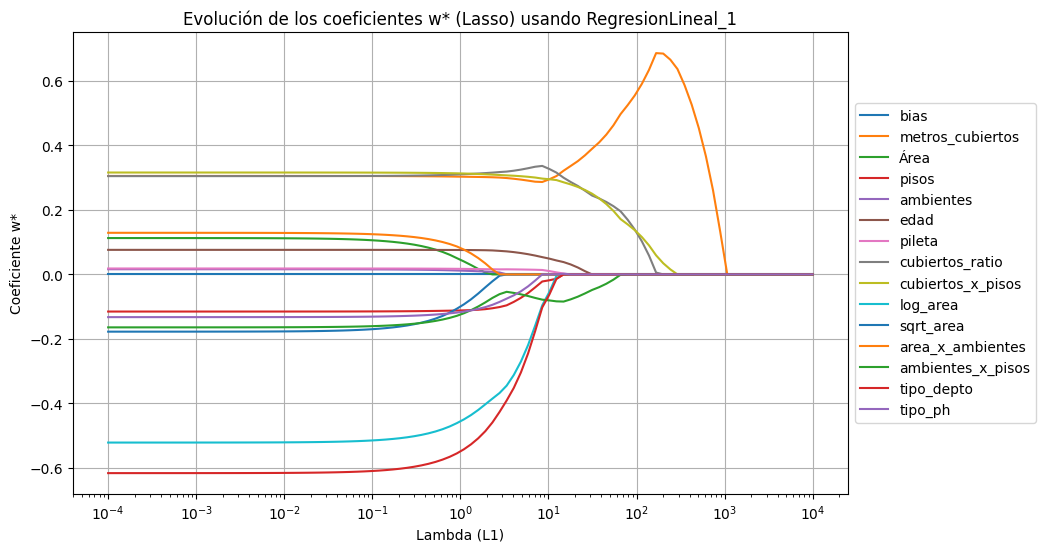

In [64]:
mu_y = y_train_M4.mean()
sigma_y = y_train_M4.std()
y_train_scaled = (y_train_M4 - mu_y) / sigma_y

lambdas = np.logspace(-4, 4, 100)
coeficientes_lasso = []

for l in lambdas:
    modelo = RegresionLineal(X_train_scaled_M4, y_train_scaled)
    modelo.array() 
    w, _ = modelo.descenso_gradiente(alpha=0.1, iteraciones=1000, lambda1=l, lambda2=0)
    coeficientes_lasso.append(w.flatten())

coeficientes_lasso = np.array(coeficientes_lasso)
print("Coeficientes Lasso shape:", coeficientes_lasso.shape)

n_coef = coeficientes_lasso.shape[1]
nombres = ["bias"] + list(X_train_scaled_M4.columns)
nombres = nombres[:n_coef]

plt.figure(figsize=(10, 6))
for i, nombre in enumerate(nombres):
    plt.plot(lambdas, coeficientes_lasso[:, i], label=nombre)

plt.xscale('log')
plt.xlabel("Lambda (L1)")
plt.ylabel("Coeficiente w*")
plt.title("Evolución de los coeficientes w* (Lasso) usando RegresionLineal_1")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()



Con respecto a la L1 los coeficientes van directamente a 0 cuando lambda crece mientras que L2 parece ser uan regularizacion o "penalidad" mas suave. Los features mas importante son los que el modelo tarda mas en penalizar o llevar a 0.

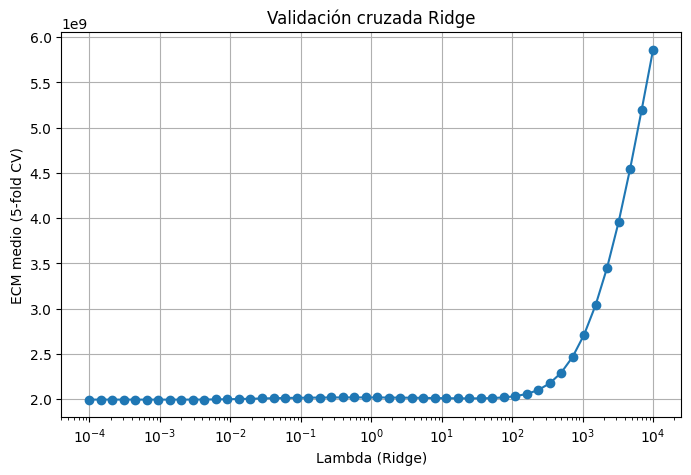

Mejor λ para Ridge: 0.0013894954943731374 con ECM: 1994280527.2874722


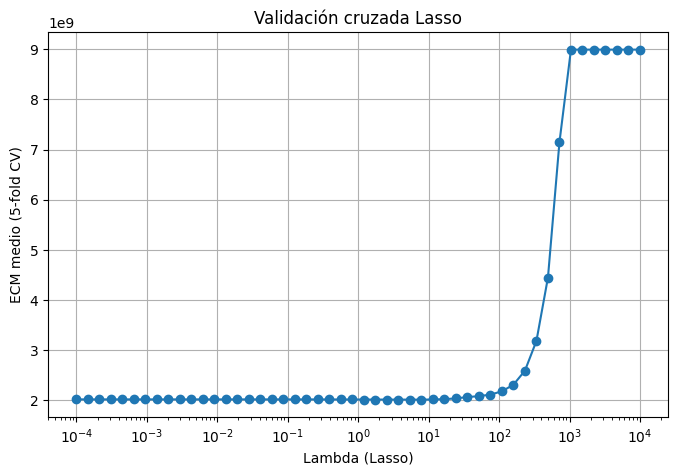

Mejor λ para Lasso: 5.428675439323859 con ECM: 2013389624.4431102


In [65]:
#cross validation
lambdas = np.logspace(-4, 4, 50)
ecm_ridge = cross_validation_ecm(RegresionLineal, X_train_M4, y_train_M4, lambdas, k=5, modo="ridge")
mejor_lambda_ridge = lambdas[np.argmin(ecm_ridge)]

plt.figure(figsize=(8,5))
plt.plot(lambdas, ecm_ridge, marker="o")
plt.xscale("log")
plt.xlabel("Lambda (Ridge)")
plt.ylabel("ECM medio (5-fold CV)")
plt.title("Validación cruzada Ridge")
plt.grid(True)
plt.show()
print("Mejor λ para Ridge:", mejor_lambda_ridge, "con ECM:", np.min(ecm_ridge))

ecm_lasso = cross_validation_ecm(RegresionLineal, X_train_M4, y_train_M4, lambdas, k=5, modo="lasso")
mejor_lambda_lasso = lambdas[np.argmin(ecm_lasso)]

plt.figure(figsize=(8,5))
plt.plot(lambdas, ecm_lasso, marker="o")
plt.xscale("log")
plt.xlabel("Lambda (Lasso)")
plt.ylabel("ECM medio (5-fold CV)")
plt.title("Validación cruzada Lasso")
plt.grid(True)
plt.show()
print("Mejor λ para Lasso:", mejor_lambda_lasso, "con ECM:", np.min(ecm_lasso))




In [66]:
#modelo m6
lam = 0.0013894954943731376

modelo_M6 = RegresionLineal(X_train_scaled_M4, y_train_M4)
modelo_M6.array()

modelo_M6.pseudoinversa(lambda2=lam)

coeficientes_ridge = modelo_M6.coef.copy()

print("Coeficientes del modelo M6 (Ridge):")
modelo_M6.imprimir_coef(nombres_columnas=X_train_scaled_M4.columns)

y_pred_M6 = modelo_M6.predecir(X_val_scaled_M4)

mse_M6 = mse(y_val_M4, y_pred_M6)
rmse_M6 = np.sqrt(mse_M6)
mae_M6 = np.mean(np.abs(y_val_M4 - y_pred_M6))

print(f"ECM (M6 - Ridge): {mse_M6}")
print(f"RMSE (M6 - Ridge): {rmse_M6}")
print(f"MAE (M6 - Ridge): {mae_M6}")


Coeficientes del modelo M6 (Ridge):
                  Feature    Coeficiente
0   Término independiente   95043.645691
1        metros_cubiertos  100936.651883
2                    Área -195960.945840
3                   pisos    7364.672341
4               ambientes    6079.912854
5                    edad    5485.899886
6                  pileta    1938.079383
7         cubiertos_ratio  -35261.967320
8       cubiertos_x_pisos   11232.523736
9                log_area -551967.656607
10              sqrt_area  625022.126466
11       area_x_ambientes   29413.183901
12      ambientes_x_pisos  -42378.148100
13             tipo_depto -108498.369908
14                tipo_ph  -20021.220422
ECM (M6 - Ridge): 2019344137.7274294
RMSE (M6 - Ridge): 44937.11314411985
MAE (M6 - Ridge): 30075.7452344952


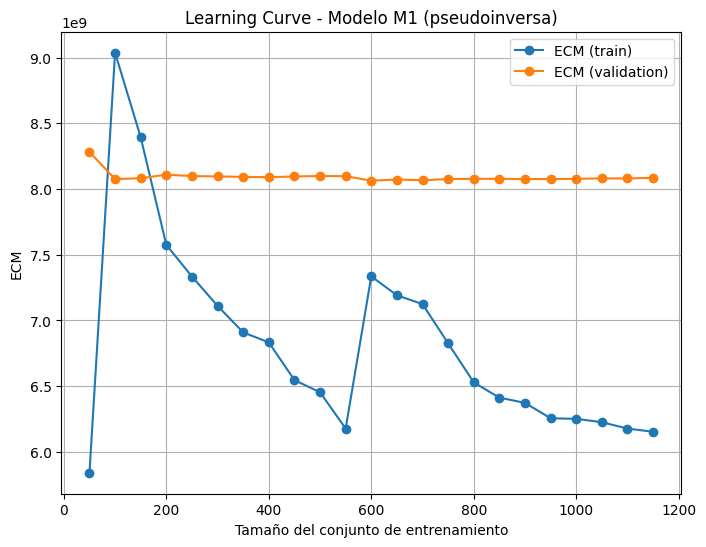

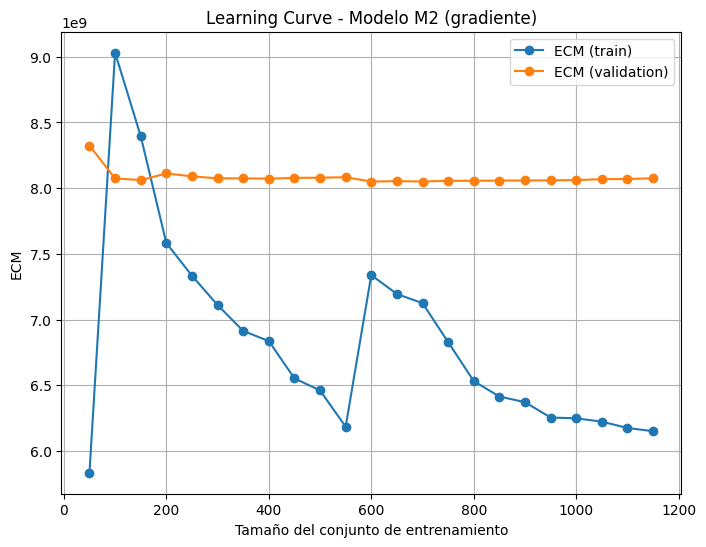

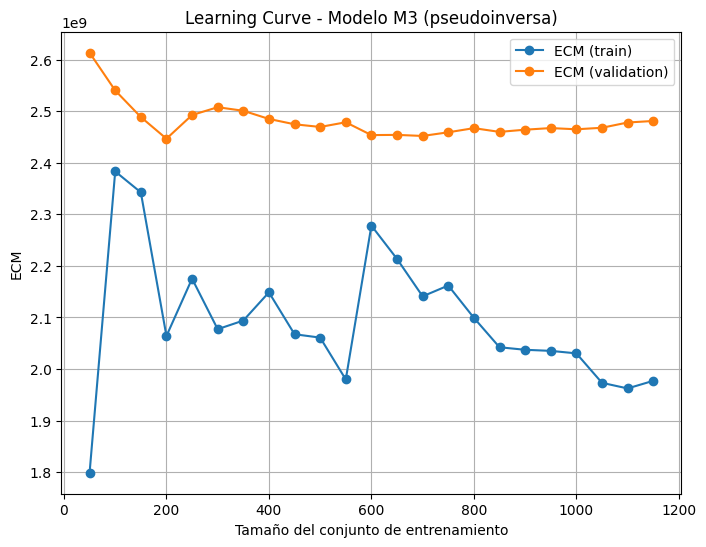

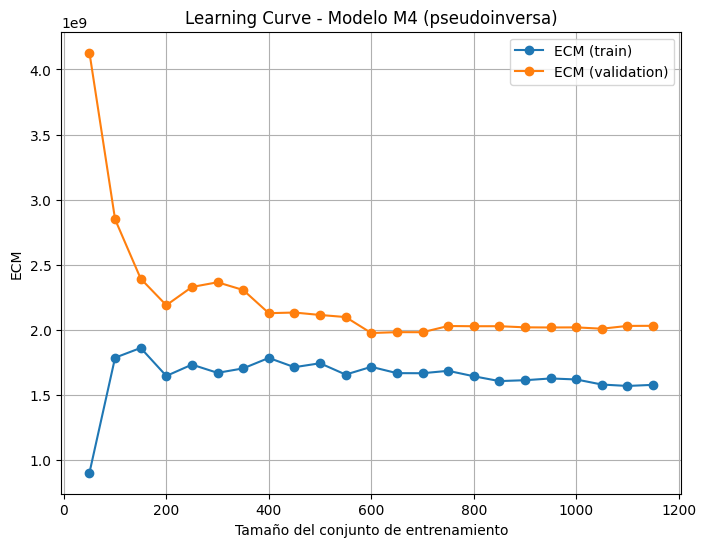

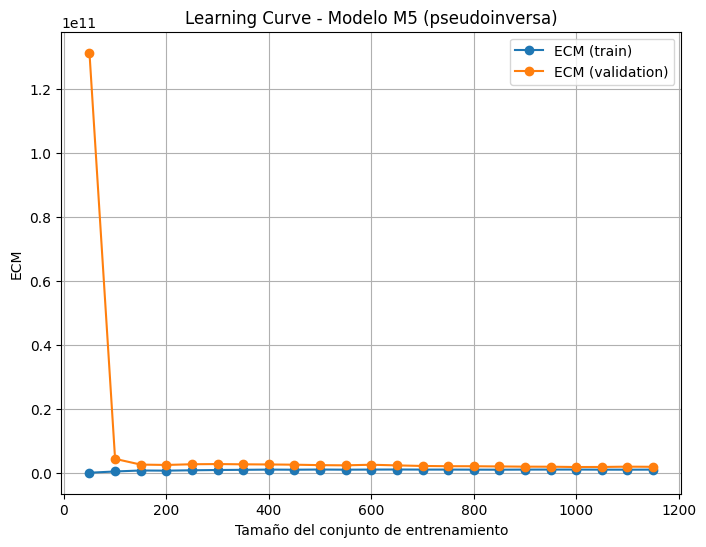

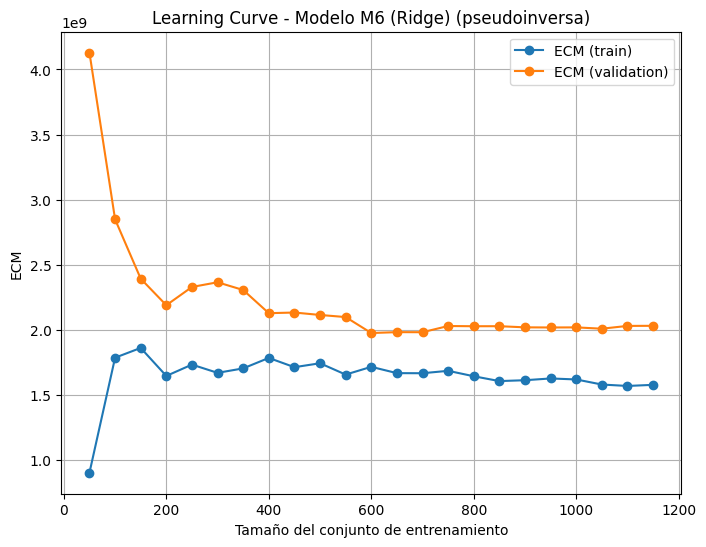

In [67]:
plot_learning_curve(RegresionLineal, X_train_M1, y_train, X_val[['Área']], y_val, "Modelo M1", metodo="pseudoinversa")
plot_learning_curve(RegresionLineal, X_train_M2, y_train, X_val[['Área','pileta']], y_val, "Modelo M2", 
                    metodo="gradiente", alpha=0.001, iteraciones=5000)
plot_learning_curve(RegresionLineal, X_train_M3, y_train, X_val[columnas_M3], y_val, "Modelo M3", metodo="pseudoinversa")
plot_learning_curve(RegresionLineal, X_train_scaled_M4, y_train_M4, X_val_scaled_M4, y_val_M4, "Modelo M4", metodo="pseudoinversa")
plot_learning_curve(RegresionLineal, X_train_M5_alt, y_train, X_val_M5_alt, y_val_aligned, "Modelo M5", metodo="pseudoinversa")

lam = 0.0013894954943731376
plot_learning_curve(RegresionLineal, X_train_scaled_M4, y_train_M4, X_val_scaled_M4, y_val_M4, 
                    "Modelo M6 (Ridge)", metodo="pseudoinversa", lambda2=lam)



Se observa poca diferencia entre el M6 y el M4 debido a que el ridge es casi nulo (hay poca penalidad para los coeficientes). No aporta mucho (nada) al modelo hacer la regularizacion en este caso.

In [68]:
df_train = pd.read_csv("datos/raw/casas_dev.csv").copy()
df_train_encoded, train_edad_mean = preprocess_and_engineer(df_train)
x_train_para_test = df_train_encoded.drop(columns=['precio']).reindex(columns=COLUMN_ORDER, fill_value=0)
y_train_para_test = df_train_encoded['precio']
df_test = pd.read_csv("datos/raw/casas_test.csv").copy()
df_test_encoded, _ = preprocess_and_engineer(df_test, edad_mean=train_edad_mean)
X_test_M4 = df_test_encoded.drop(columns=['precio']).reindex(columns=COLUMN_ORDER, fill_value=0)
y_test_M4 = df_test_encoded['precio']
X_train_scaled_M4, X_test_scaled_M4, mu, sigma = z_score_normalize(x_train_para_test, X_test_M4)

modelo_M4 = RegresionLineal(X_train_scaled_M4, y_train_para_test)
modelo_M4.x = np.hstack([np.ones((X_train_scaled_M4.shape[0], 1)), X_train_scaled_M4])

modelo_M4.pseudoinversa()
coef_pseudo_inversa = modelo_M4.coef.copy()

print("Coeficientes luego de entrenar por pseudoinversa:")
modelo_M4.imprimir_coef(nombres_columnas=x_train_para_test.columns)

y_pred_pseudo_inversa = np.dot( np.hstack([np.ones((X_test_scaled_M4.shape[0], 1)), X_test_scaled_M4]), modelo_M4.coef)

mse_pseudo_inversa = mse(y_test_M4, y_pred_pseudo_inversa)
rmse_pseudo_inversa = rmse(y_test_M4, y_pred_pseudo_inversa)
mae_pseudo_inversa = mae(y_test_M4, y_pred_pseudo_inversa)

print(f"\nECM para el modelo con pseudo-inversa: {mse_pseudo_inversa:.4f}")
print(f"RMSE para el modelo con pseudo-inversa: {rmse_pseudo_inversa:.4f}")
print(f"MAE para el modelo con pseudo-inversa: {mae_pseudo_inversa:.4f}")

Coeficientes luego de entrenar por pseudoinversa:
                  Feature    Coeficiente
0   Término independiente   96919.358168
1        metros_cubiertos   78647.786992
2                    Área   12711.796950
3                   pisos    4735.423189
4               ambientes    5492.774467
5                    edad    5188.963344
6                  pileta    1886.879283
7         cubiertos_ratio  -17875.726073
8       cubiertos_x_pisos   20254.834072
9                log_area -296256.349585
10              sqrt_area  160057.946462
11       area_x_ambientes   30351.224470
12      ambientes_x_pisos  -42407.965722
13             tipo_depto -113131.329480
14                tipo_ph  -21589.136114

ECM para el modelo con pseudo-inversa: 1762160074.2538
RMSE para el modelo con pseudo-inversa: 41978.0904
MAE para el modelo con pseudo-inversa: 27550.3221


COMENTARIOS:

De todos los modelos usaria el M4, debido a que es el que mejor podria generalizar, en comparacion con el M5 que tiene mas riesgo de overtitting al tener tantas features. El M4 llega a un buen punto entre bias y varianza.